# Zero-inflation gate vs. plain LGCP

The LGCP is a smooth spatio-temporal process model: even in a grid
cell/date that is *always* zero (e.g. outside the fishing grounds), it can
still predict a small positive rate, since its kernels smooth across
neighboring nonzero observations.

This notebook adds an optional **zero-inflation gate**: a small MLP
classifier (`src/models/zero_gate.py`) trained to predict `y > 0` from the
same standardized features the LGCP sees. At evaluation time, wherever the
classifier predicts "zero", the LGCP's predicted rate is forced to 0.
It's wired into `scripts/11_train_lgcp.py` behind a config switch
(`zero_gate.enabled`, default `false`) — see
`config/train_basic_lgcp_multi_kernel.yaml`.

Here we compare **LGCP** vs. **LGCP + zero-gate** on the same test window,
years, and LGCP hyperparameters selected in
`51_paper_lgcp_window_selection_baselines.ipynb` (hardcoded below as
variables, taken from that notebook's results rather than re-searched).

In [1]:
from __future__ import annotations

import copy
import importlib.util
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.metrics_lgcp import evaluate_metrics
from src.models.zero_gate import train_zero_gate, apply_zero_gate, build_zero_gate_features


def load_script_module(name, relpath):
    spec = importlib.util.spec_from_file_location(name, PROJECT_ROOT / relpath)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


train_lgcp = load_script_module("train_lgcp", "scripts/11_train_lgcp.py")

print("Modules loaded OK.")

Modules loaded OK.


## Configuration

Window, years, and LGCP hyperparameters are hardcoded here from the
results of notebook 51 (window Pareto-front selection + baseline grid
search), not re-derived. `ZERO_GATE_CFG` matches the defaults in
`config/train_basic_lgcp_multi_kernel.yaml`'s `zero_gate` block.

In [2]:
YEARS = [2024, 2025]

# --- from notebook 51: selected window + winning LGCP config ---
SELECTED_TEST_START = "2025-05-01"
SELECTED_TEST_END = "2025-05-07"
BEST_LGCP_KERNEL = "yearly"
BEST_LGCP_LR = 0.001
NUM_MC = 32
NUM_STEPS_FINAL = 5000
M_INDUCING = 300
SEED = 0

PERIOD_SPECS = {"weekly": 7.0, "monthly": 30.44, "yearly": 365.25}

ZERO_GATE_CFG = {
    "hidden_layer_sizes": [128],
    "activation": "relu",
    "alpha": 1e-4,
    "max_iter": 5000,
    "threshold": 0.3,
}

BASE_LGCP_CONFIG = PROJECT_ROOT / "config/train_basic_lgcp_multi_kernel.yaml"
RESULTS_DIR = PROJECT_ROOT / "reports" / "paper" / "zero_gate_2025_05_01"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Test window: {SELECTED_TEST_START} .. {SELECTED_TEST_END}")
print(f"LGCP config: kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  num_mc={NUM_MC}  num_steps={NUM_STEPS_FINAL}")
print(f"Results will be saved under: {RESULTS_DIR}")

Test window: 2025-05-01 .. 2025-05-07
LGCP config: kernel=yearly  lr=0.001  num_mc=32  num_steps=5000
Results will be saved under: /home/rdoz/PhD/AIPS/reports/paper/zero_gate_2025_05_01


In [3]:
base_cfg = train_lgcp.load_config(str(BASE_LGCP_CONFIG))
base_cfg["years"] = YEARS
base_cfg["M_inducing"] = M_INDUCING
base_cfg["parquet_path"] = str(PROJECT_ROOT / base_cfg["parquet_path"])


def period_to_std(period_days: float, t_scaler, span_days: float) -> float:
    period_t_norm = period_days / span_days
    return period_t_norm / float(t_scaler.scale_[0])


def build_temporal_model_cfg(base_model_cfg: dict, period_std: float) -> dict:
    model_cfg = copy.deepcopy(base_model_cfg)
    model_cfg["temporal_kernels"] = [
        {
            "type": "RBF",
            "hyperparameters": {"lengthscale": 0.08, "variance": 0.5},
            "trainable": {"lengthscale": True, "variance": True},
        },
        {
            "type": "periodic",
            "hyperparameters": {"lengthscale": 0.50, "variance": 0.2, "period": period_std},
            "trainable": {"lengthscale": True, "variance": True, "period": False},
        },
    ]
    return model_cfg


print("base_cfg loaded, helpers defined.")

base_cfg loaded, helpers defined.


## Load data and train the LGCP once (raw predictions)

In [4]:
(
    train_coords, train_covs, train_y,
    test_coords, test_covs, test_y,
    scalers, df,
) = train_lgcp.prepare_data(
    base_cfg["parquet_path"],
    train_fraction=base_cfg["train_fraction"],
    random_seed=base_cfg["data_seed"],
    split_strategy="fixed_test_window",
    covariate_cols=base_cfg["covariate_cols"],
    test_start_date=SELECTED_TEST_START,
    test_end_date=SELECTED_TEST_END,
    lag_features=base_cfg.get("lag_features"),
    years=YEARS,
)
_, test_mask = train_lgcp.make_day_split_masks(
    df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
    split_strategy="fixed_test_window", test_start_date=SELECTED_TEST_START, test_end_date=SELECTED_TEST_END,
)
test_dates = df.loc[test_mask, "date"].values
span_days = (df["date"].max() - df["date"].min()).days
t_scaler = scalers["t_scaler"]

print(f"Train obs: {train_coords.shape[0]:,}   Test obs: {test_coords.shape[0]:,}")
print(f"True zeros in test set: {(test_y == 0).sum()}/{len(test_y)}  "
      f"({(test_y == 0).mean():.1%})")

Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
Train obs: 23,814   Test obs: 343
True zeros in test set: 307/343  (89.5%)


In [5]:
period_std = period_to_std(PERIOD_SPECS[BEST_LGCP_KERNEL], t_scaler, span_days)
model_cfg = build_temporal_model_cfg(base_cfg["model"], period_std)

run_cfg = dict(base_cfg)
run_cfg["model"] = model_cfg
run_cfg["kernel_config"] = train_lgcp.normalize_kernel_config(run_cfg)
run_cfg["lr"] = BEST_LGCP_LR
run_cfg["num_mc"] = NUM_MC
run_cfg["num_steps"] = NUM_STEPS_FINAL
run_cfg["log_every"] = 500
m_inducing = min(run_cfg["M_inducing"], train_coords.shape[0])

train_lgcp.set_seeds(SEED)
model = train_lgcp.SparseLGCP(
    train_coords, train_covs, train_y,
    kernel_config=run_cfg["kernel_config"],
    M_inducing=m_inducing,
    device=run_cfg["device"],
    np_seed=SEED,
)
train_lgcp.configure_log_noise(model, run_cfg)

print(f"Training LGCP (kernel={BEST_LGCP_KERNEL}, lr={BEST_LGCP_LR}, num_steps={NUM_STEPS_FINAL}) …")
t0 = time.time()
train_lgcp.train(model, run_cfg)
print(f"Done in {time.time() - t0:.1f}s")

rate_mean_test, _, _ = model.predict_rate(
    test_coords, test_covs, num_samples=run_cfg.get("num_pred_samples", 200)
)
metrics_raw = evaluate_metrics(test_y, rate_mean_test, test_dates)
print("\nRaw LGCP test metrics:")
for k, v in metrics_raw.items():
    print(f"  {k}: {v:.4f}")


=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
Training LGCP (kernel=yearly, lr=0.001, num_steps=5000) …
[     1/5000]  loss=369842.4062  ll=-15872.4492  kl=714.9666  (0.1s)
[   500/5000]  loss=9941.3105  ll=-412.4370  kl=349.7332  (17.2s)
[  1000/5000]  loss=8465.1582  ll=-348.1313  kl=369.0657  (34.3s)
[  1500/5000]  loss=7860.8496  ll=-322.0905  kl=370.3595  (51.4s)
[  2000/5000]  loss=8700.6357  ll=-357.8983  kl=377.4025  (68.3s)
[  2500/5000]  loss=8203.4922  ll=-336.5077  kl=377.7168  (85.1s)
[  3000/5000]  loss=8778.0771  ll=-361.0057  kl=382.5795  (102.3s)
[  3500/5000]  loss=7145.1841  ll=-290.4002  kl=391.6766  (119.8s)
[  4000/5000]  loss=8783.8467  ll=-361.1850  kl=384.1787  (136.9s)
[  4500/5000]  loss=7836.7334  ll=-320.2605  kl=388.7996  (154.1s)
[  5000/5000]  loss=8381.9180  ll=-343.6003  kl=391.1970  (171.4s)
Done in 172.1s

Raw LGCP test metrics:
  mean_ll_obs: -0.3916
  mae_obs: 0.2501
  rmse_obs: 0.7216
  mean_ll_daily: -6.0291
  mae_dai

## Train the zero-inflation gate and apply it to the same predictions

In [6]:
zero_gate_clf = train_zero_gate(train_coords, train_covs, train_y, ZERO_GATE_CFG, seed=SEED)

rate_mean_test_gated = apply_zero_gate(
    zero_gate_clf, test_coords, test_covs, rate_mean_test,
    threshold=ZERO_GATE_CFG["threshold"],
)
metrics_gated = evaluate_metrics(test_y, rate_mean_test_gated, test_dates)

n_gated = int((rate_mean_test_gated == 0).sum())
print(f"Zero-gate forced {n_gated}/{len(rate_mean_test_gated)} test predictions to 0 "
      f"(threshold={ZERO_GATE_CFG['threshold']}).")
print("\nLGCP + zero-gate test metrics:")
for k, v in metrics_gated.items():
    print(f"  {k}: {v:.4f}")

Zero-gate forced 274/343 test predictions to 0 (threshold=0.3).

LGCP + zero-gate test metrics:
  mean_ll_obs: -1.1628
  mae_obs: 0.2148
  rmse_obs: 0.7290
  mean_ll_daily: -5.9400
  mae_daily: 7.0457
  rmse_daily: 11.0601
  daily_delta_corr: 0.2060
  daily_direction_accuracy_moving: 0.5000


## Gate quality diagnostics

How well does the classifier actually separate zero from nonzero on the
*test* set? This is the key thing to check before trusting the gate: a
gate that mislabels many true nonzero observations as zero will hurt
recall on exactly the events (vessel presence) the whole pipeline cares
about.

In [7]:
X_test_gate = build_zero_gate_features(test_coords, test_covs)
y_test_nonzero = (test_y > 0).astype(int)
pred_nonzero = zero_gate_clf.predict(X_test_gate)

cm = confusion_matrix(y_test_nonzero, pred_nonzero, labels=[0, 1])
cm_df = pd.DataFrame(
    cm, index=["true: zero", "true: nonzero"], columns=["pred: zero", "pred: nonzero"]
)
print("Confusion matrix (test set):")
display(cm_df)

print(classification_report(y_test_nonzero, pred_nonzero, target_names=["zero", "nonzero"], digits=3))

n_false_zeroed = int(cm[1, 0])  # true nonzero, predicted zero -- the risky error
print(f"True nonzero observations incorrectly forced to 0: {n_false_zeroed}/{int(y_test_nonzero.sum())} "
      f"({n_false_zeroed / max(int(y_test_nonzero.sum()), 1):.1%} of all true nonzeros)")

Confusion matrix (test set):


,pred: zero,pred: nonzero
true: zero,277,30
true: nonzero,16,20


              precision    recall  f1-score   support

        zero      0.945     0.902     0.923       307
     nonzero      0.400     0.556     0.465        36

    accuracy                          0.866       343
   macro avg      0.673     0.729     0.694       343
weighted avg      0.888     0.866     0.875       343

True nonzero observations incorrectly forced to 0: 16/36 (44.4% of all true nonzeros)


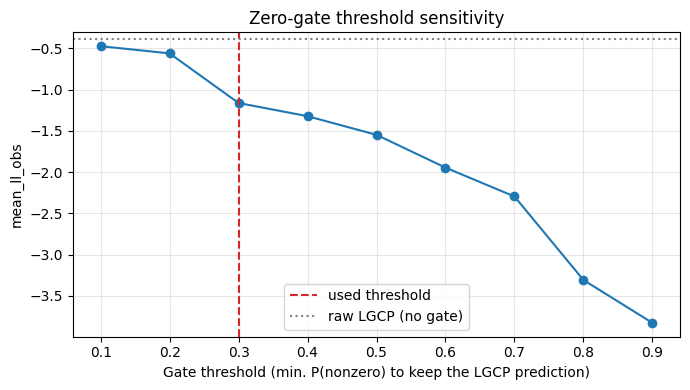

In [8]:
# Bonus: sensitivity to the gating threshold (no retraining needed --
# reuses the same trained classifier and LGCP predictions).
thresholds = np.round(np.arange(0.1, 1.0, 0.1), 2)
nonzero_class_idx = list(zero_gate_clf.classes_).index(1)
proba_nonzero = zero_gate_clf.predict_proba(X_test_gate)[:, nonzero_class_idx]

threshold_rows = []
for thr in thresholds:
    gated = rate_mean_test.copy()
    gated[proba_nonzero < thr] = 0.0
    m = evaluate_metrics(test_y, gated, test_dates)
    threshold_rows.append({"threshold": thr, **m})

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(RESULTS_DIR / "zero_gate_threshold_sensitivity.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(threshold_df["threshold"], threshold_df["mean_ll_obs"], marker="o")
ax.axvline(ZERO_GATE_CFG["threshold"], color="tab:red", linestyle="--", label="used threshold")
ax.axhline(metrics_raw["mean_ll_obs"], color="gray", linestyle=":", label="raw LGCP (no gate)")
ax.set_xlabel("Gate threshold (min. P(nonzero) to keep the LGCP prediction)")
ax.set_ylabel("mean_ll_obs")
ax.set_title("Zero-gate threshold sensitivity")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "zero_gate_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparison table

In [9]:
metric_keys = list(metrics_raw.keys())

comparison_rows = [
    {"method": "LGCP", "n_forced_to_zero": 0, **{k: metrics_raw[k] for k in metric_keys}},
    {
        "method": "LGCP + zero-gate",
        "n_forced_to_zero": n_gated,
        **{k: metrics_gated[k] for k in metric_keys},
    },
]
comparison_df = pd.DataFrame(comparison_rows).set_index("method")
comparison_df.to_csv(RESULTS_DIR / "lgcp_vs_zero_gate.csv")

print(f"Test window: {SELECTED_TEST_START} .. {SELECTED_TEST_END}   "
      f"({int((test_y == 0).sum())}/{len(test_y)} true zeros)")
print(f"Results saved under: {RESULTS_DIR}\n")
comparison_df

Test window: 2025-05-01 .. 2025-05-07   (307/343 true zeros)
Results saved under: /home/rdoz/PhD/AIPS/reports/paper/zero_gate_2025_05_01



,n_forced_to_zero,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
method,,,,,,,,,
LGCP,0,-0.391555,0.250071,0.721558,-6.029116,6.736790,10.668161,0.285739,0.75
LGCP + zero-gate,274,-1.162796,0.214840,0.729027,-5.939979,7.045655,11.060140,0.206042,0.50


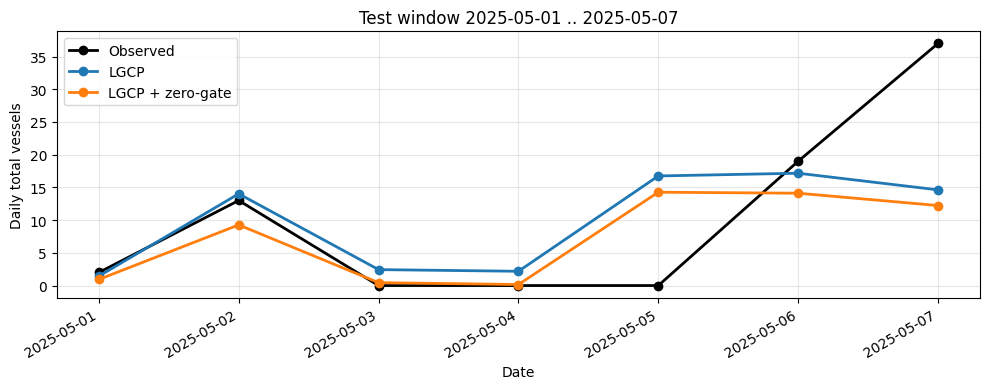

In [10]:
daily = (
    pd.DataFrame({
        "date": pd.to_datetime(test_dates),
        "observed": test_y,
        "LGCP": rate_mean_test,
        "LGCP + zero-gate": rate_mean_test_gated,
    })
    .groupby("date", as_index=False)
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily["date"], daily["observed"], label="Observed", color="black", lw=2, marker="o")
ax.plot(daily["date"], daily["LGCP"], label="LGCP", lw=2, marker="o")
ax.plot(daily["date"], daily["LGCP + zero-gate"], label="LGCP + zero-gate", lw=2, marker="o")
ax.set_xlabel("Date")
ax.set_ylabel("Daily total vessels")
ax.set_title(f"Test window {SELECTED_TEST_START} .. {SELECTED_TEST_END}")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "daily_timeseries_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Notes for the paper writeup**

- Both rows are the identical trained LGCP (kernel=`yearly`, lr=0.001,
  num_mc=32, num_steps=5000, same window/years as notebook 51); the gate
  is a post-hoc correction applied only to `LGCP + zero-gate`'s test
  predictions, not a retraining.
- The confusion matrix / classification report above is the honest thing
  to report alongside any metric improvement: gains in `mean_ll_obs` /
  `rmse_*` need to be weighed against how many true-nonzero observations
  the gate incorrectly zeroed out.
- `zero_gate_threshold_sensitivity.csv/png` shows how the result would
  change with a stricter/looser gate, in case a different `threshold` is
  worth justifying in the paper instead of the config default of 0.5.
- To use this in production runs (not just this notebook), set
  `zero_gate.enabled: true` in the LGCP config
  (see `config/train_basic_lgcp_multi_kernel.yaml`); it's `false` by
  default.